# Persistence in LangGraph:

### A mechanism that serializes and stores graph state across executions so workflows can be resumed, replayed, and inspected deterministically

In [43]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage
from langgraph.graph.message import add_messages,BaseMessage
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()

True

In [44]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [45]:
class Chat(TypedDict):
    topic : str
    joke : str
    joke_explanation : str

In [46]:
def generate_joke(state:Chat):
    joke = llm.invoke(f"Generate a small 1 or 2 line joke on {state['topic']}")

    state['joke']=joke

    return state

In [47]:
def joke_explanation(state:Chat):

    joke_exp = llm.invoke(f"Generate a small explanation on {state['joke']}")

    state['joke_explanation']=joke_exp

    return state

In [48]:
graph = StateGraph(Chat)

In [49]:
graph.add_node('generate_joke',generate_joke)
graph.add_node('joke_explanation',joke_explanation)

In [50]:
graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','joke_explanation')
graph.add_edge('joke_explanation',END)

In [51]:
workflow = graph.compile()

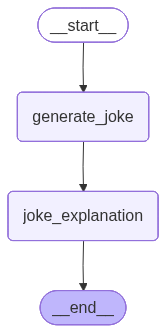

In [52]:
workflow

In [53]:
input = {'topic':"New Year"}

output = workflow.invoke(input)

In [54]:
output

{'topic': 'New Year',
 'joke': AIMessage(content='Why do New Year’s resolutions work best at the gym? Because they can’t get “weighted” down!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 20, 'total_tokens': 43, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'id': 'chatcmpl-CtXtM8CoMAsvw5K0ltpsIyJ4U8CdK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--c1d79435-2d7a-430c-8700-2efc21e61c6e-0', usage_metadata={'input_tokens': 20, 'output_tokens': 23, 'total_tokens': 43, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
 'joke_explanation': AIMessage(content='The joke "Why do New Year’s resolutio

## Implementing Persistent

In [55]:
checkpointer = InMemorySaver()

workflow2 = graph.compile(checkpointer=checkpointer)

In [64]:
config = {"configurable":{"thread_id":1}}
input = {'topic':"New Year"}

output = workflow2.invoke(input,config=config)

output

{'topic': 'New Year',
 'joke': AIMessage(content='Why did the calendar break up with the clock? Because it felt like they were just ticking away the days! Happy New Year! 🎉', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 20, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'id': 'chatcmpl-CtXyBsQsdR1Jb5i6eOEI9op9fVfGP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--bd1093ad-419e-477b-9fd5-9603b8ecb758-0', usage_metadata={'input_tokens': 20, 'output_tokens': 28, 'total_tokens': 48, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
 'joke_explanation': AIMessage(content='The jo

In [65]:
# Here we will get the end state of the memory
workflow2.get_state(config)

StateSnapshot(values={'topic': 'New Year', 'joke': AIMessage(content='Why did the calendar break up with the clock? Because it felt like they were just ticking away the days! Happy New Year! 🎉', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 20, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'id': 'chatcmpl-CtXyBsQsdR1Jb5i6eOEI9op9fVfGP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--bd1093ad-419e-477b-9fd5-9603b8ecb758-0', usage_metadata={'input_tokens': 20, 'output_tokens': 28, 'total_tokens': 48, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), 'joke_explanation': AIMess

In [66]:
# If we want to get the intermediate states
list(workflow2.get_state_history(config))

[StateSnapshot(values={'topic': 'New Year', 'joke': AIMessage(content='Why did the calendar break up with the clock? Because it felt like they were just ticking away the days! Happy New Year! 🎉', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 20, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'id': 'chatcmpl-CtXyBsQsdR1Jb5i6eOEI9op9fVfGP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--bd1093ad-419e-477b-9fd5-9603b8ecb758-0', usage_metadata={'input_tokens': 20, 'output_tokens': 28, 'total_tokens': 48, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), 'joke_explanation': AIMes

# If we run paraller still we can get unique data of each thread using thread ID

In [67]:
checkpointer = InMemorySaver()

workflow3 = graph.compile(checkpointer=checkpointer)

In [69]:
config1 = {"configurable":{"thread_id":2}}
input = {'topic':"Pizza"}

output = workflow3.invoke(input,config=config1)

output

{'topic': 'Pizza',
 'joke': AIMessage(content='Why did the pizza maker always carry a pencil?  \nBecause he wanted to draw some dough!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 19, 'total_tokens': 38, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'id': 'chatcmpl-CtXzfnEIo39EXIndwMv5jwECk6C0q', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--e44e4dca-b381-434a-9935-eae062fa790b-0', usage_metadata={'input_tokens': 19, 'output_tokens': 19, 'total_tokens': 38, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
 'joke_explanation': AIMessage(content='This joke plays on a clever wordplay that co

In [72]:
# Here we will get the end state of the memory
workflow3.get_state(config1)

StateSnapshot(values={'topic': 'Pizza', 'joke': AIMessage(content='Why did the pizza maker always carry a pencil?  \nBecause he wanted to draw some dough!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 19, 'total_tokens': 38, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'id': 'chatcmpl-CtXzfnEIo39EXIndwMv5jwECk6C0q', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--e44e4dca-b381-434a-9935-eae062fa790b-0', usage_metadata={'input_tokens': 19, 'output_tokens': 19, 'total_tokens': 38, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), 'joke_explanation': AIMessage(content='This joke plays on a clev

In [71]:
# If we want to get the intermediate states
list(workflow3.get_state_history(config1))

[StateSnapshot(values={'topic': 'Pizza', 'joke': AIMessage(content='Why did the pizza maker always carry a pencil?  \nBecause he wanted to draw some dough!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 19, 'total_tokens': 38, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'id': 'chatcmpl-CtXzfnEIo39EXIndwMv5jwECk6C0q', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--e44e4dca-b381-434a-9935-eae062fa790b-0', usage_metadata={'input_tokens': 19, 'output_tokens': 19, 'total_tokens': 38, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), 'joke_explanation': AIMessage(content='This joke plays on a cle

# Benefits of Persistent

# 1. Time Travel

### Historical state snapshots allow replay, debugging, and rollback to prior versions.

In [75]:
# Get the state from which we want to execute the flow again
workflow3.get_state({"configurable":{"thread_id":2,"checkpoint_id":"1f0e7d18-259b-64f7-8000-5f34f9a8b9d4"}})

StateSnapshot(values={'topic': 'Pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f0e7d18-259b-64f7-8000-5f34f9a8b9d4'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-01-02T11:52:26.957847+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7d18-2595-6848-bfff-74697144f547'}}, tasks=(PregelTask(id='cbf7aee4-b2c4-9866-1cca-438a820c4513', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'topic': 'Pizza', 'joke': AIMessage(content='Why did the pizza maker always carry a pencil?  \nBecause he wanted to draw some dough!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 19, 'total_tokens': 38, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_de

In [ ]:
# I wanted to execute it from where joke want generated
workflow3.invoke(None,{"configurable":{"thread_id":2,"checkpoint_id":"1f0e7d18-259b-64f7-8000-5f34f9a8b9d4"}})

{'topic': 'Pizza',
 'joke': AIMessage(content="Why did the pizza maker go broke? Because he just couldn't make enough dough!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 19, 'total_tokens': 35, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c4585b5b9c', 'id': 'chatcmpl-CtYRJ4EgZBPqSL2huGjbgtFsbvitT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--3810008b-b4ba-4555-9b3d-ee019b58fae9-0', usage_metadata={'input_tokens': 19, 'output_tokens': 16, 'total_tokens': 35, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
 'joke_explanation': AIMessage(content='The joke "Why did the pizza maker go broke? Because he

In [79]:
list(workflow3.get_state_history(config1))
# SO now we will get different joke on same topic Pizza

[StateSnapshot(values={'topic': 'Pizza', 'joke': AIMessage(content="Why did the pizza maker go broke? Because he just couldn't make enough dough!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 19, 'total_tokens': 35, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c4585b5b9c', 'id': 'chatcmpl-CtYRJ4EgZBPqSL2huGjbgtFsbvitT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--3810008b-b4ba-4555-9b3d-ee019b58fae9-0', usage_metadata={'input_tokens': 19, 'output_tokens': 16, 'total_tokens': 35, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), 'joke_explanation': AIMessage(content='The joke "Why did the pizza maker 

# 2. Update the State

### persisted intermediate node state enables step-to-step context continuity.

In [82]:
workflow3.update_state({"configurable":{"thread_id":2,"checkpoint_id":"1f0e7d18-2595-6848-bfff-74697144f547","checkpoint_ns":""}},{"topic":"samosa"})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0e7e18-d151-633e-8000-31ccf01dbe56'}}

In [83]:
list(workflow3.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7e18-d151-633e-8000-31ccf01dbe56'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-01-02T13:47:16.911187+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7d18-2595-6848-bfff-74697144f547'}}, tasks=(PregelTask(id='66f3a0f1-f9f1-e0f6-dd62-6190bc1a2f38', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'samosa', 'joke': AIMessage(content='Why did the pizza maker always carry a pencil?  \nBecause he wanted to draw some dough!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 19, 'total_tokens': 38, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, '

In [87]:
workflow3.invoke(None,{"configurable":{"thread_id":2,"checkpoint_id":"1f0e7e18-d151-633e-8000-31ccf01dbe56"}})

{'topic': 'samosa',
 'joke': AIMessage(content="Why did the samosa go to school?  \nBecause it wanted to be a little 'more filling'!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 20, 'total_tokens': 42, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'id': 'chatcmpl-CtZqdneNhejsYyo6vrQIa9a8LmMWV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--f334b014-db1e-41bc-a675-d229637fa1bf-0', usage_metadata={'input_tokens': 20, 'output_tokens': 22, 'total_tokens': 42, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
 'joke_explanation': AIMessage(content='The joke "Why did the samosa go to school? Bec

# 3. Fault Tolerance

### Crashed or interrupted runs can be recovered from the last committed checkpoint.

Simple Workflow --> will implement 3 steps in step 2 will add one keyboard interupt and the workflow will resume from that step only.

<pre>
Start
  |
Step 1
  |
Step 2 (Will interrupt here)
  |
Step 3 {Workflow will resume from here}
  |
 END
</pre>

In [91]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import time
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: Union[str, ForwardRef('os.PathLike[str]'), NoneType] = None, stream: Optional[IO[str]] = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: Optional[str] = 'utf-8') -> bool>

In [90]:
class demo(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [92]:
def step_1(state:demo):
    print("Step 1 executed")
    return {"step1":"done","input":state['input']}

In [94]:
def step_2(state:demo):
    print("Step 2 hanging... interrupt manual")
    time.sleep(30)
    return {"step2":"done"}

In [ ]:
def step_3(state:demo):
    print("Step 3 Done")
    return {"step3":"Done"}

In [97]:
graph = StateGraph(demo)

In [98]:
graph.add_node("step_1",step_1)
graph.add_node("step_2",step_2)
graph.add_node("step_3",step_3)

In [102]:
graph.add_edge(START,"step_1")
graph.add_edge("step_1","step_2")
graph.add_edge("step_2","step_3")
graph.add_edge("step_3",END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [103]:
checkpointer5 = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer5)

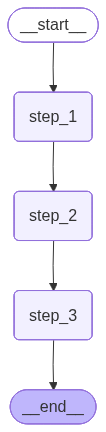

In [105]:
workflow

In [107]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    workflow.invoke({"input": "start"}, config={"configurable": {"thread_id": "thread-1"}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")


▶️ Running graph: Please manually interrupt during Step 2...
Step 1 executed
Step 2 hanging... interrupt manual
❌ Kernel manually interrupted (crash simulated).


In [109]:
workflow.get_state({"configurable": {"thread_id": "thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7e48-1900-6477-8001-9459734899c9'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-01-02T14:08:26.074431+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7e48-18fb-637c-8000-0f1fe7de460f'}}, tasks=(PregelTask(id='7bdaa616-46b7-ef2f-21cc-5acf3729dd77', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [111]:
list(workflow.get_state_history({"configurable": {"thread_id": "thread-1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7e48-1900-6477-8001-9459734899c9'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-01-02T14:08:26.074431+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7e48-18fb-637c-8000-0f1fe7de460f'}}, tasks=(PregelTask(id='7bdaa616-46b7-ef2f-21cc-5acf3729dd77', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7e48-18fb-637c-8000-0f1fe7de460f'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-01-02T14:08:26.072358+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch

In [112]:
final_state = workflow.invoke(None, config={"configurable": {"thread_id": "thread-1"}})
print("\n✅ Final State:", final_state)


Step 2 hanging... interrupt manual
Step 3 Done

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}
